# Food Delivery Business Performance Analysis

## Data Loading and Initial Exploration

First, let's load the dataset into a pandas DataFrame and get a preliminary understanding of its structure, including column names, data types, and non-null values.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Day14_Food_Delivery_Visualization_Dataset.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [2]:
# Display basic information about the DataFrame (columns, non-null values, data types)
print("\nDataFrame Information:")
df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  Cu

## Time-Series Analysis: Orders and Revenue Over Time

To understand the business performance across different periods, I will analyze the trends of total orders and revenue over time. Line plots are ideal for visualizing such temporal patterns.

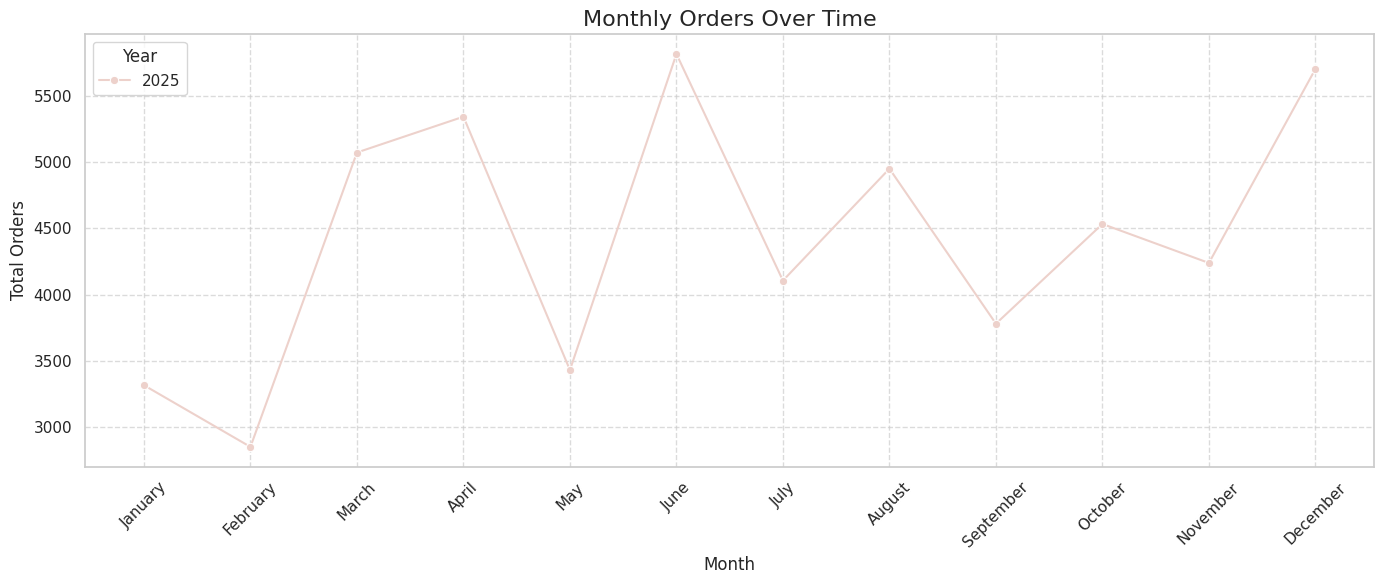

Interpretation: This line plot displays the total number of orders received each month. By observing the trend, we can identify peak seasons or months with higher order volumes, which could be attributed to various factors such as holidays, promotional activities, or seasonal demand. The plot helps in understanding the overall growth or fluctuations in order frequency over the observed period.


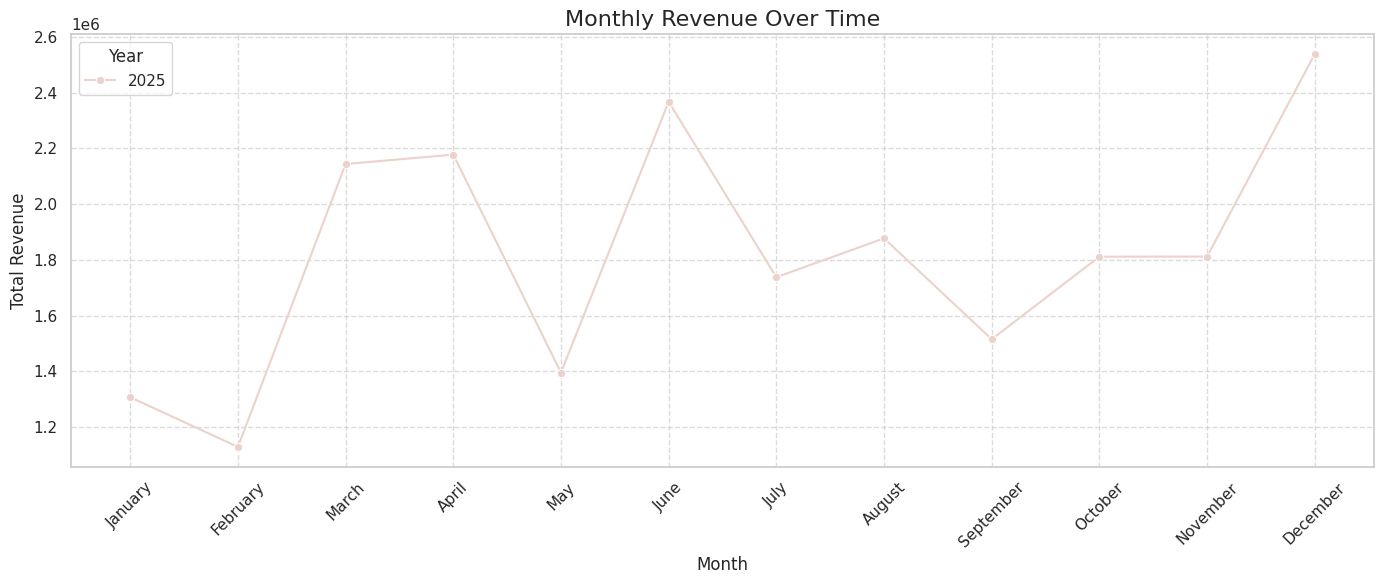

Interpretation: This line plot illustrates the total revenue generated each month. Similar to the orders plot, it helps in identifying periods of high and low revenue, indicating the financial performance and potential growth trajectories of the business. Comparing this with the orders plot can reveal if changes in order volume directly correlate with revenue changes, or if average order value plays a significant role in revenue fluctuations.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters in one step
sns.set_theme(style="whitegrid", palette="viridis")

# Aggregate data by Month and Year for time-series analysis
monthly_performance = df.groupby(['Year', 'Month', 'Month_Name'])[['Orders', 'Revenue']].sum().reset_index()

# Ensure correct month order for plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_performance['Month_Name'] = pd.Categorical(monthly_performance['Month_Name'], categories=month_order, ordered=True)
monthly_performance = monthly_performance.sort_values(by=['Year', 'Month_Name'])

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_performance, x='Month_Name', y='Orders', marker='o', hue='Year', legend='full')
plt.title('Monthly Orders Over Time', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation: This line plot displays the total number of orders received each month. By observing the trend, we can identify peak seasons or months with higher order volumes, which could be attributed to various factors such as holidays, promotional activities, or seasonal demand. The plot helps in understanding the overall growth or fluctuations in order frequency over the observed period.")


plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_performance, x='Month_Name', y='Revenue', marker='o', hue='Year', legend='full')
plt.title('Monthly Revenue Over Time', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation: This line plot illustrates the total revenue generated each month. Similar to the orders plot, it helps in identifying periods of high and low revenue, indicating the financial performance and potential growth trajectories of the business. Comparing this with the orders plot can reveal if changes in order volume directly correlate with revenue changes, or if average order value plays a significant role in revenue fluctuations.")

## Performance Analysis by City and Cuisine

To identify key markets and popular food categories, I will analyze total orders and revenue grouped by 'City' and 'Cuisine' using bar charts.

/tmp/ipykernel_2302/3209923788.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Orders', data=city_performance, palette='viridis')


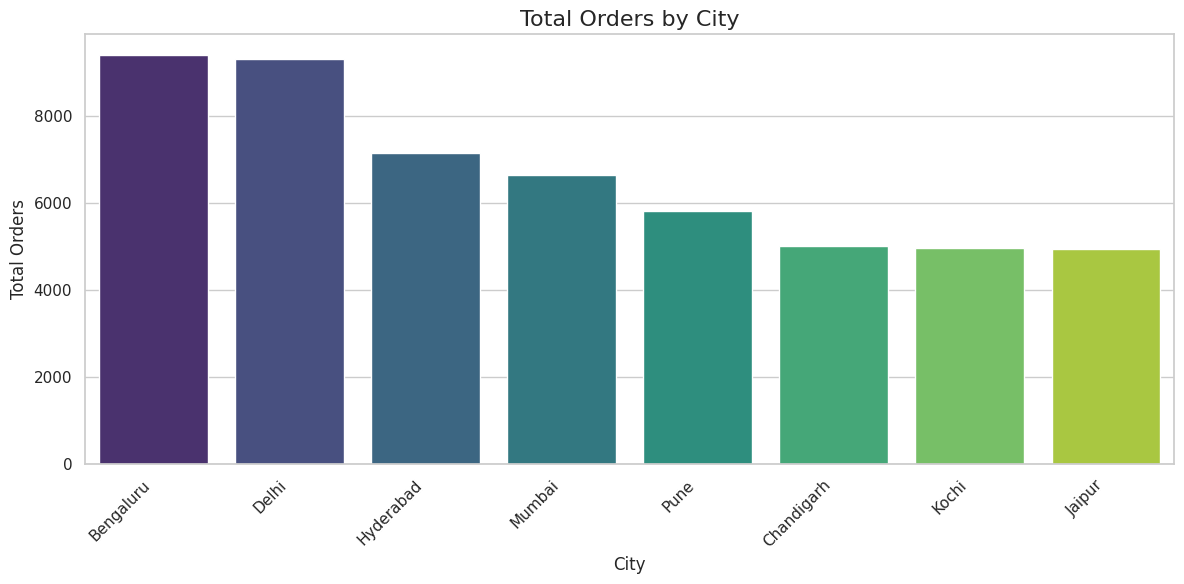

Interpretation: This bar chart displays the total number of orders from each city. It helps in identifying which cities are the strongest markets in terms of order volume, suggesting where the customer base is most active or where marketing efforts might be most effective.


/tmp/ipykernel_2302/3209923788.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Revenue', data=city_performance, palette='viridis')


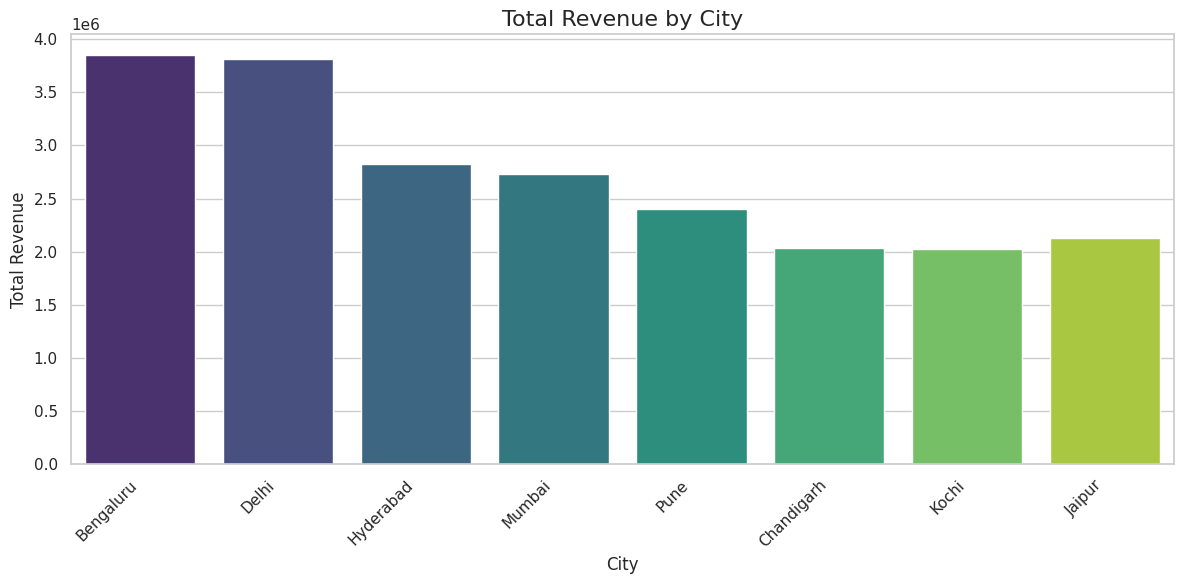

Interpretation: This bar chart shows the total revenue generated from each city. By comparing this with the 'Orders by City' chart, we can see if higher order volumes consistently lead to higher revenue, or if some cities have a higher average order value, contributing significantly to revenue despite fewer orders.


In [5]:
# Aggregate data by City for orders and revenue
city_performance = df.groupby('City')[['Orders', 'Revenue']].sum().reset_index()

# Sort for better visualization
city_performance = city_performance.sort_values(by='Orders', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='City', y='Orders', data=city_performance, palette='viridis')
plt.title('Total Orders by City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart displays the total number of orders from each city. It helps in identifying which cities are the strongest markets in terms of order volume, suggesting where the customer base is most active or where marketing efforts might be most effective.")

plt.figure(figsize=(12, 6))
sns.barplot(x='City', y='Revenue', data=city_performance, palette='viridis')
plt.title('Total Revenue by City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart shows the total revenue generated from each city. By comparing this with the 'Orders by City' chart, we can see if higher order volumes consistently lead to higher revenue, or if some cities have a higher average order value, contributing significantly to revenue despite fewer orders.")

/tmp/ipykernel_2302/465306038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cuisine', y='Orders', data=cuisine_performance, palette='magma')


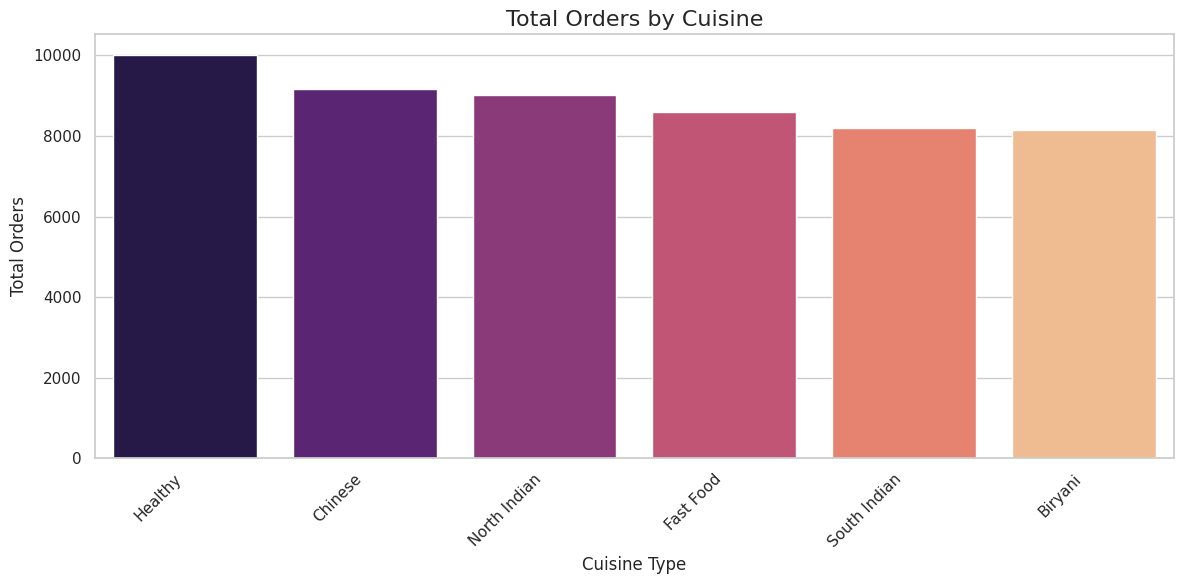

Interpretation: This bar chart illustrates the total orders for each cuisine type. It highlights the most popular cuisines, indicating customer preferences and potentially guiding menu development or marketing strategies for less popular cuisines.


/tmp/ipykernel_2302/465306038.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cuisine', y='Revenue', data=cuisine_performance, palette='magma')


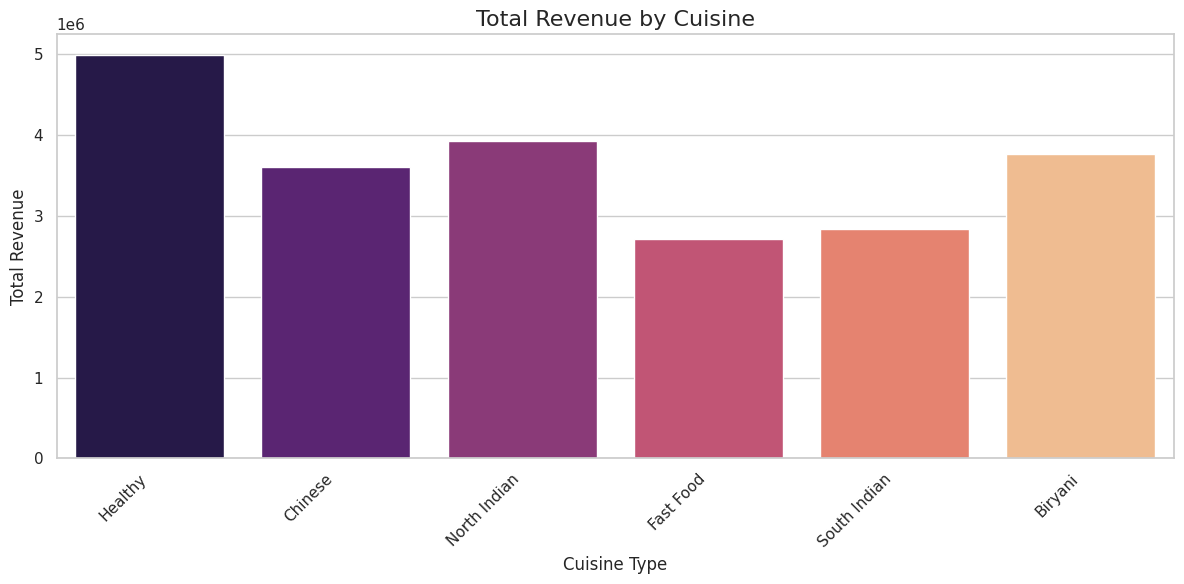

Interpretation: This bar chart shows the total revenue generated by each cuisine type. This provides insight into which cuisines are not only popular but also generate the most income. Discrepancies between order volume and revenue for certain cuisines could indicate differences in pricing or average dish cost.


In [6]:
# Aggregate data by Cuisine for orders and revenue
cuisine_performance = df.groupby('Cuisine')[['Orders', 'Revenue']].sum().reset_index()

# Sort for better visualization
cuisine_performance = cuisine_performance.sort_values(by='Orders', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Cuisine', y='Orders', data=cuisine_performance, palette='magma')
plt.title('Total Orders by Cuisine', fontsize=16)
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart illustrates the total orders for each cuisine type. It highlights the most popular cuisines, indicating customer preferences and potentially guiding menu development or marketing strategies for less popular cuisines.")

plt.figure(figsize=(12, 6))
sns.barplot(x='Cuisine', y='Revenue', data=cuisine_performance, palette='magma')
plt.title('Total Revenue by Cuisine', fontsize=16)
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart shows the total revenue generated by each cuisine type. This provides insight into which cuisines are not only popular but also generate the most income. Discrepancies between order volume and revenue for certain cuisines could indicate differences in pricing or average dish cost.")

## Relationship Between Marketing Spend and Revenue

To understand the effectiveness of marketing efforts, I will visualize the relationship between 'Marketing_Spend' and 'Revenue' using a scatter plot. This will help identify if increased marketing spend leads to higher revenue.

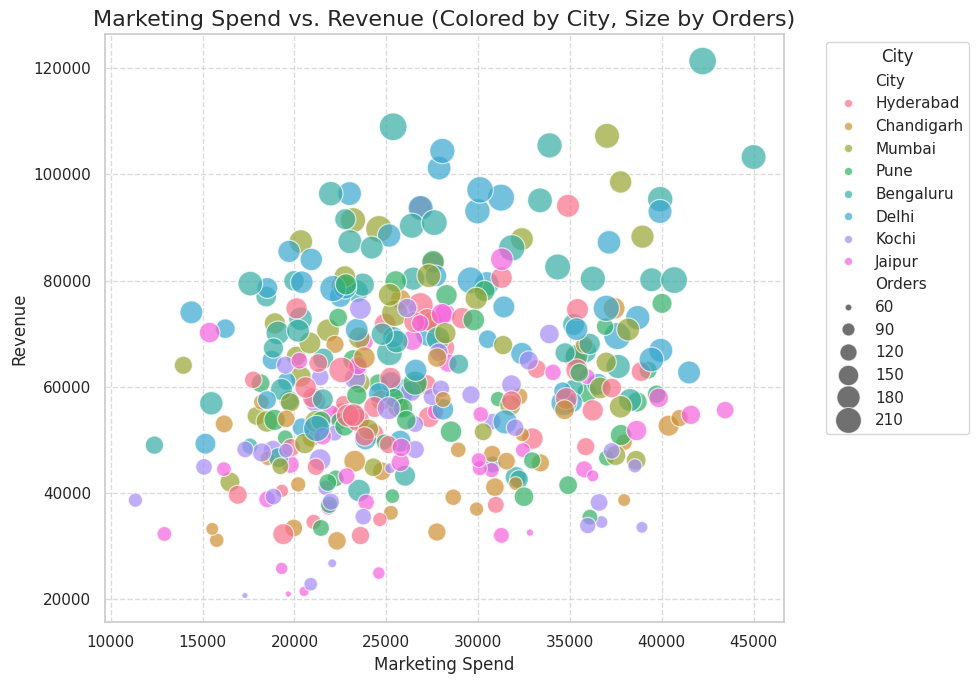

Interpretation: This scatter plot visualizes the relationship between marketing spend and revenue. Each point represents a data entry (e.g., a day's performance). The plot allows us to observe if there's a positive correlation: as marketing spend increases, does revenue tend to increase? Coloring by city and sizing by orders can add further dimensions to the analysis, potentially revealing that certain cities respond better to marketing efforts or that marketing spend is more effective when order volumes are higher.


In [7]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Marketing_Spend', y='Revenue', data=df, hue='City', size='Orders', sizes=(20, 400), alpha=0.7)
plt.title('Marketing Spend vs. Revenue (Colored by City, Size by Orders)', fontsize=16)
plt.xlabel('Marketing Spend', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Interpretation: This scatter plot visualizes the relationship between marketing spend and revenue. Each point represents a data entry (e.g., a day's performance). The plot allows us to observe if there's a positive correlation: as marketing spend increases, does revenue tend to increase? Coloring by city and sizing by orders can add further dimensions to the analysis, potentially revealing that certain cities respond better to marketing efforts or that marketing spend is more effective when order volumes are higher.")

## Delivery Time and Customer Ratings

Understanding how delivery time impacts customer satisfaction is crucial. I will use a scatter plot to visualize the relationship between 'Avg_Delivery_Minutes' and 'Customer_Rating' to see if there's a correlation.

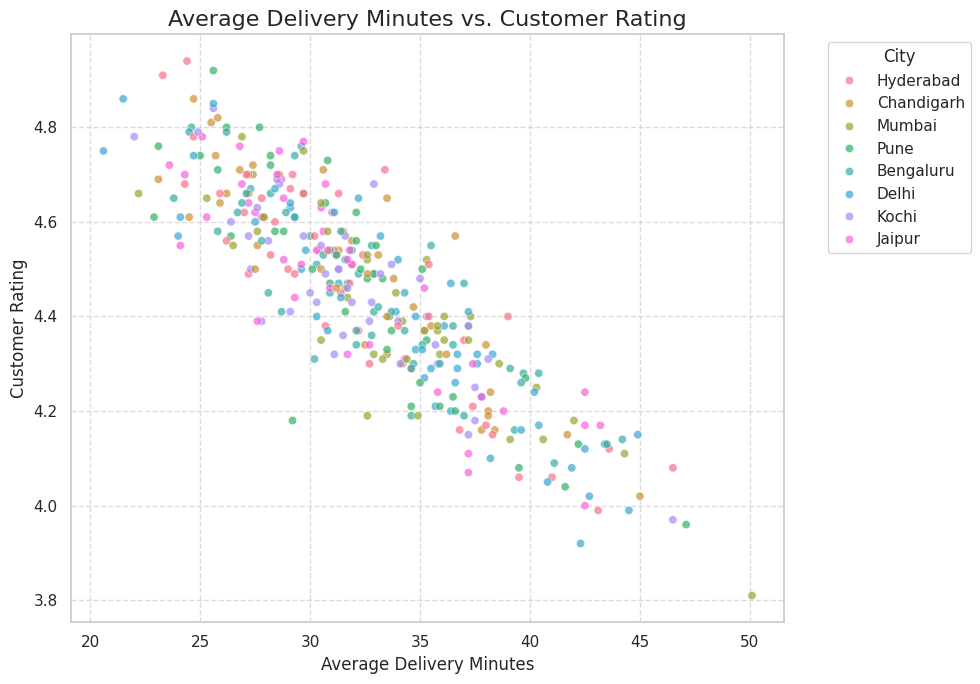

Interpretation: This scatter plot displays the relationship between the average delivery time and customer ratings. It helps to identify if longer delivery times generally lead to lower customer ratings or if there are other factors at play. The hue (city) can reveal if this relationship varies across different cities.


In [8]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Avg_Delivery_Minutes', y='Customer_Rating', data=df, alpha=0.7, hue='City')
plt.title('Average Delivery Minutes vs. Customer Rating', fontsize=16)
plt.xlabel('Average Delivery Minutes', fontsize=12)
plt.ylabel('Customer Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Interpretation: This scatter plot displays the relationship between the average delivery time and customer ratings. It helps to identify if longer delivery times generally lead to lower customer ratings or if there are other factors at play. The hue (city) can reveal if this relationship varies across different cities.")

## Data Preprocessing for Time Series Analysis

To analyze trends over time, I will convert the 'Date' column to a datetime format and extract the year and month, which will be useful for grouping and plotting.

In [3]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract year and month for time-based analysis
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.month_name()

# Display DataFrame info again to confirm changes
print("\nDataFrame Information after date preprocessing:")
df.info()

# Display the first few rows with the new columns
print("\nFirst 5 rows of the dataset with new date columns:")
display(df.head())


DataFrame Information after date preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    object        
 3   Day                      360 non-null    object        
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent,Year,Month_Name
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1,2025,March
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4,2025,April
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0,2025,January
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2,2025,June
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9,2025,August


## Correlation Heatmap

To understand the linear relationships between numerical variables in the dataset, I will generate a correlation heatmap. This visualization helps in identifying strong positive or negative correlations, which can reveal underlying patterns and dependencies.

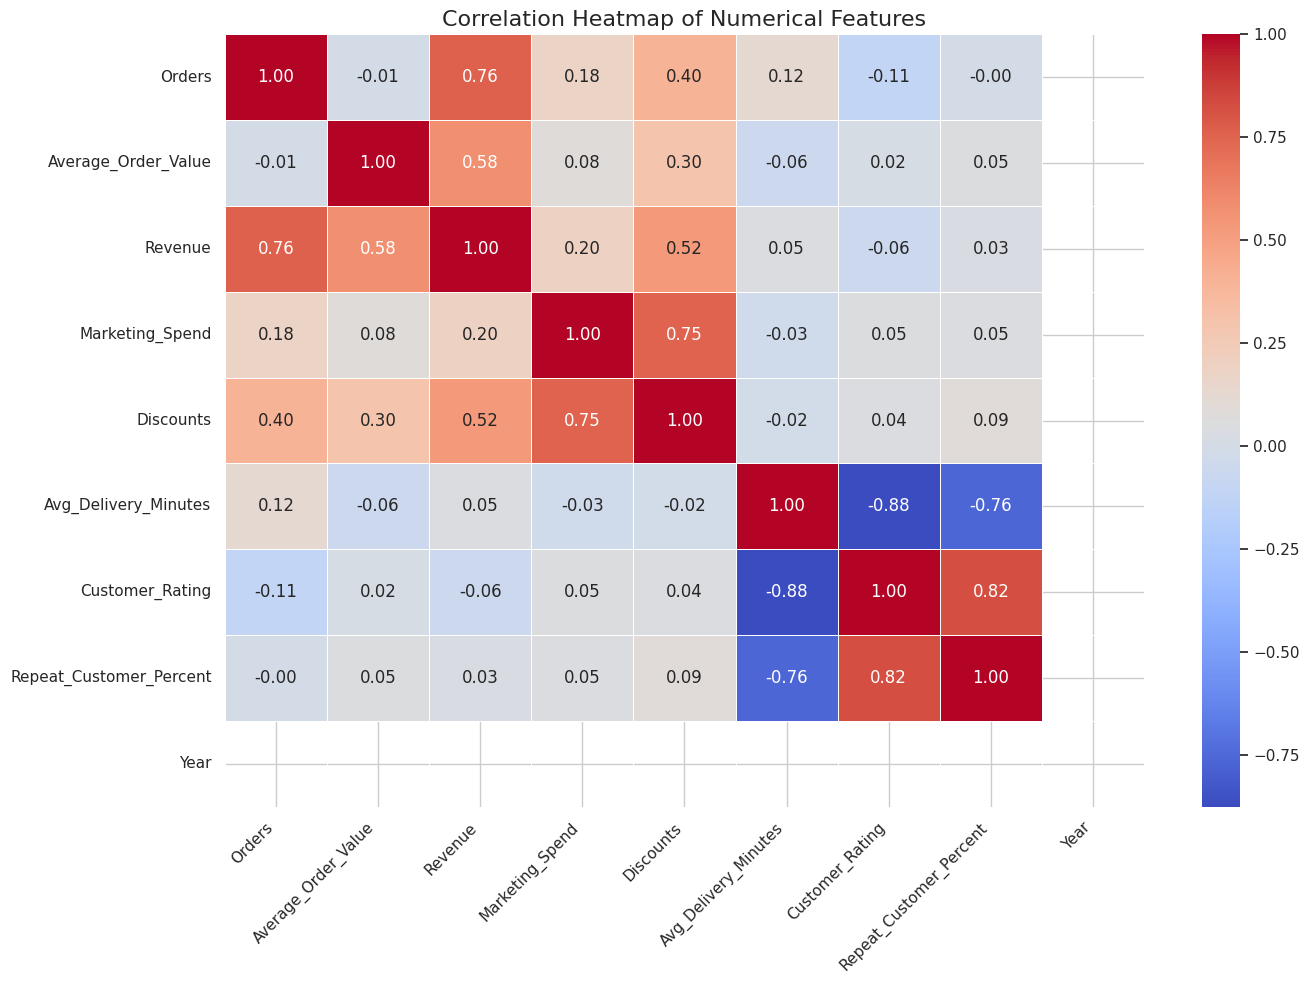

Interpretation: This heatmap displays the pairwise correlation coefficients between all numerical variables. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation. This plot can reveal which metrics move together, such as Marketing_Spend and Revenue, or Avg_Delivery_Minutes and Customer_Rating.


In [11]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Interpretation: This heatmap displays the pairwise correlation coefficients between all numerical variables. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation. This plot can reveal which metrics move together, such as Marketing_Spend and Revenue, or Avg_Delivery_Minutes and Customer_Rating.")

## Summary of Key Findings

Based on the visualizations and analysis, here are the most important findings regarding the food delivery business performance:

1.  **Time-based Trends (Orders & Revenue):** The business exhibits clear monthly fluctuations in both orders and revenue, with notable peaks (e.g., June, August, December) and troughs (e.g., February, May). This suggests seasonality that could be leveraged for marketing and operational planning.

2.  **City Performance:** Bengaluru and Delhi are consistently the top-performing cities in terms of both total orders and total revenue. This indicates strong market presence and customer demand in these regions. Other cities like Hyderabad and Mumbai also show significant activity.

3.  **Cuisine Popularity:** 'Healthy' cuisine leads in both total orders and revenue, suggesting a strong customer preference for healthier options. Chinese and North Indian cuisines also perform well. Understanding these preferences can help in menu optimization and targeted promotions.

4.  **Marketing Spend Effectiveness:** The scatter plot of Marketing Spend vs. Revenue shows a general positive correlation, indicating that increased marketing efforts tend to lead to higher revenue. However, the varying spread suggests that the efficiency of marketing spend might differ across cities and order volumes.

5.  **Delivery Time and Customer Satisfaction:** There appears to be a negative correlation between average delivery minutes and customer ratings: longer delivery times generally correspond to lower customer ratings. This highlights the critical importance of efficient delivery operations for customer satisfaction. The impact might also vary slightly by city.

6.  **Impact of Weather Conditions:** 'Clear' weather conditions contribute to the highest number of orders and revenue, while 'Hot' weather sees the lowest. 'Cloudy' and 'Rainy' conditions fall in between. This data can inform staffing levels and marketing strategies during different weather patterns.

7.  **Order Channel Performance:** The 'App' is the dominant order channel, generating significantly more orders and revenue compared to 'Website' and 'Partner Platform'. This emphasizes the importance of a robust mobile application experience and could guide investment priorities for channel development.

8.  **Overall Correlations (from Heatmap):**
    *   `Revenue` has a strong positive correlation with `Orders` and `Marketing_Spend`, confirming that more orders and higher marketing investment generally lead to higher revenue.
    *   `Customer_Rating` shows a strong negative correlation with `Avg_Delivery_Minutes`, reinforcing the importance of quick delivery for customer satisfaction.
    *   `Repeat_Customer_Percent` also has a moderate positive correlation with `Customer_Rating`, indicating that satisfied customers are more likely to be repeat customers.

These findings provide actionable insights for optimizing marketing strategies, improving operational efficiency, tailoring menus, and focusing on customer satisfaction to drive business growth.

## Impact of Weather Conditions and Order Channels on Performance

To understand external and operational factors, I will examine how different 'Weather' conditions and 'Order_Channel' types affect total orders and revenue using bar charts.

/tmp/ipykernel_2302/1856981997.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='Orders', data=weather_performance, palette='coolwarm')


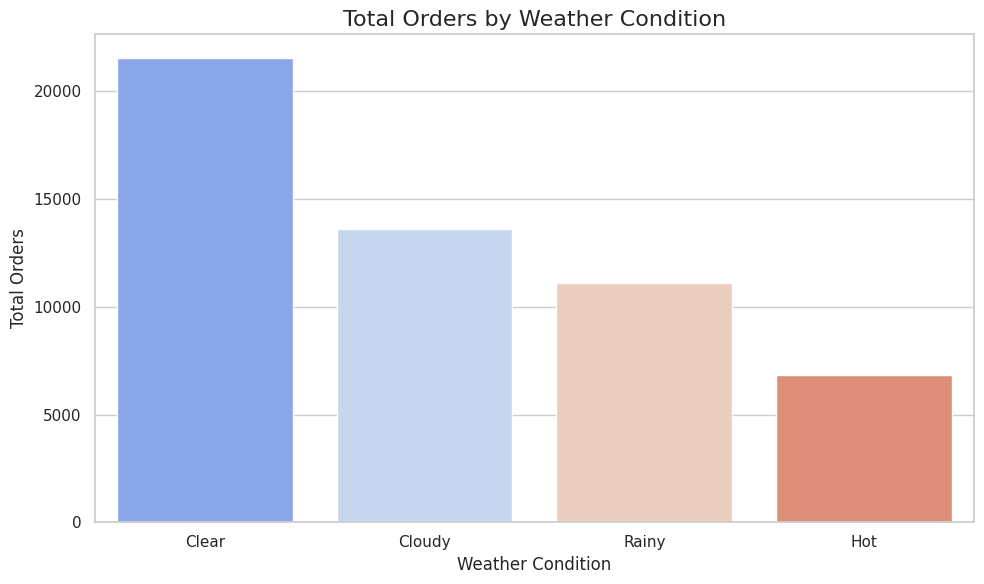

/tmp/ipykernel_2302/1856981997.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='Revenue', data=weather_performance, palette='coolwarm')


Interpretation: This bar chart shows the total orders placed under different weather conditions. It helps in understanding if certain weather types, such as rain or heat, significantly influence customer ordering behavior, which can be useful for staffing and promotional planning.


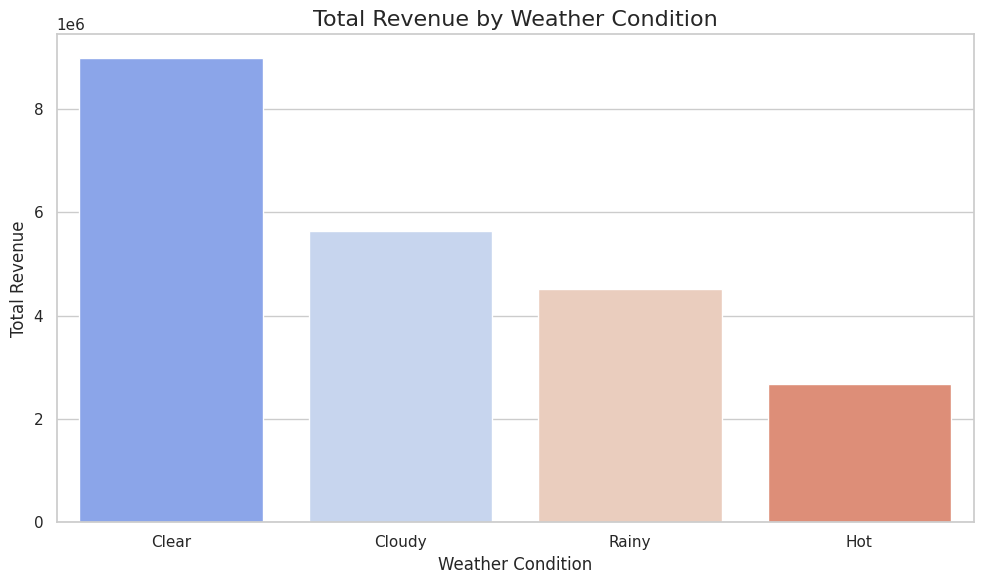

Interpretation: This bar chart illustrates the total revenue generated under various weather conditions. By comparing this with the orders plot, we can assess if revenue patterns align with order patterns during different weather, or if average order values change under specific conditions.


In [9]:
# Aggregate data by Weather for orders and revenue
weather_performance = df.groupby('Weather')[['Orders', 'Revenue']].sum().reset_index()

# Sort for better visualization
weather_performance = weather_performance.sort_values(by='Orders', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weather', y='Orders', data=weather_performance, palette='coolwarm')
plt.title('Total Orders by Weather Condition', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart shows the total orders placed under different weather conditions. It helps in understanding if certain weather types, such as rain or heat, significantly influence customer ordering behavior, which can be useful for staffing and promotional planning.")

plt.figure(figsize=(10, 6))
sns.barplot(x='Weather', y='Revenue', data=weather_performance, palette='coolwarm')
plt.title('Total Revenue by Weather Condition', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart illustrates the total revenue generated under various weather conditions. By comparing this with the orders plot, we can assess if revenue patterns align with order patterns during different weather, or if average order values change under specific conditions.")

/tmp/ipykernel_2302/185529183.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order_Channel', y='Orders', data=channel_performance, palette='crest')


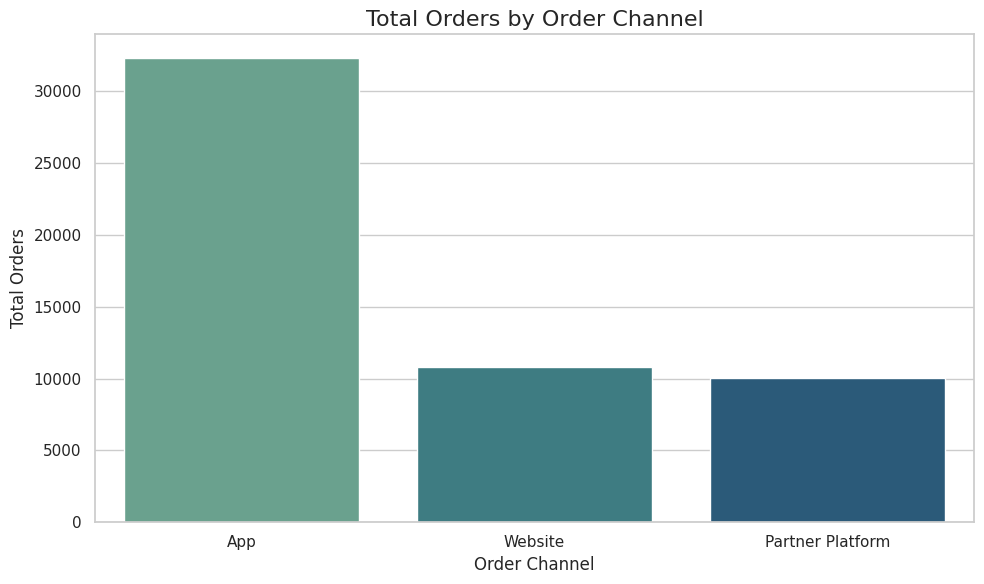

/tmp/ipykernel_2302/185529183.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order_Channel', y='Revenue', data=channel_performance, palette='crest')


Interpretation: This bar chart displays the total orders received through different order channels (e.g., App, Website, Partner Platform). It helps in identifying the most effective channels for order acquisition and can inform decisions regarding investment and optimization of these platforms.


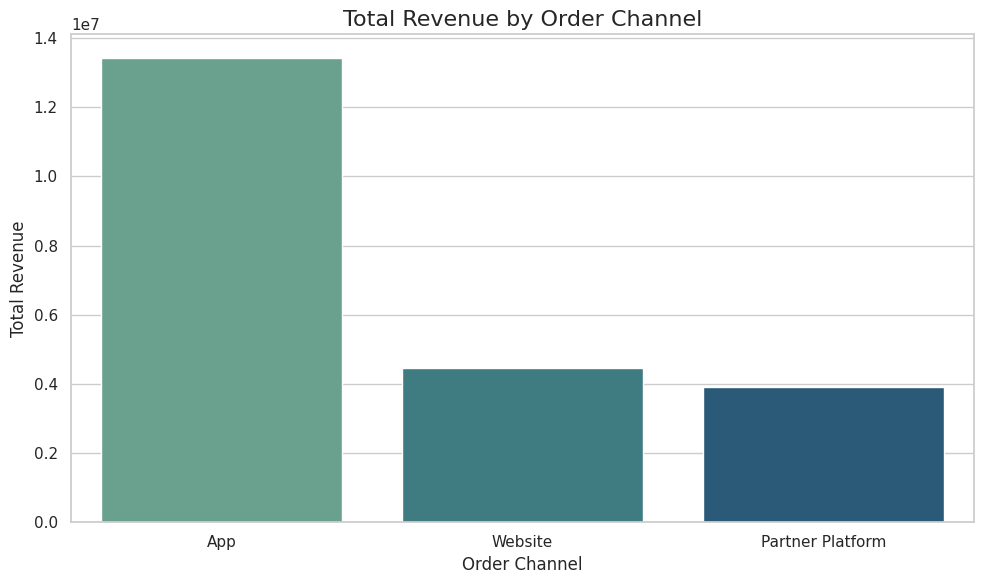

Interpretation: This bar chart illustrates the total revenue generated by each order channel. Similar to the orders plot, this provides insight into the financial contribution of each channel. Analyzing both orders and revenue by channel can highlight channels that, despite lower order volume, generate higher revenue due to higher average order values.


In [10]:
# Aggregate data by Order_Channel for orders and revenue
channel_performance = df.groupby('Order_Channel')[['Orders', 'Revenue']].sum().reset_index()

# Sort for better visualization
channel_performance = channel_performance.sort_values(by='Orders', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Order_Channel', y='Orders', data=channel_performance, palette='crest')
plt.title('Total Orders by Order Channel', fontsize=16)
plt.xlabel('Order Channel', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart displays the total orders received through different order channels (e.g., App, Website, Partner Platform). It helps in identifying the most effective channels for order acquisition and can inform decisions regarding investment and optimization of these platforms.")

plt.figure(figsize=(10, 6))
sns.barplot(x='Order_Channel', y='Revenue', data=channel_performance, palette='crest')
plt.title('Total Revenue by Order Channel', fontsize=16)
plt.xlabel('Order Channel', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation: This bar chart illustrates the total revenue generated by each order channel. Similar to the orders plot, this provides insight into the financial contribution of each channel. Analyzing both orders and revenue by channel can highlight channels that, despite lower order volume, generate higher revenue due to higher average order values.")